# Knightian Uncertainty Demonstration

Compare InfraBayesianAgent behavior with and without Knightian uncertainty (KU).

**Non-KU** (single belief): The infradistribution contains one a-measure. Lambda=1, b=0; the IB plumbing is a pass-through. Equivalent to standard Bayesian updating.

**KU** (multiple beliefs): The infradistribution contains multiple a-measures with different priors. At each step, the agent:
1. Takes the element-wise **min** over all measures' reward models (worst-case planning)
2. Updates each measure via **Definition 11** from *Basic Inframeasure Theory* — rescaling lambda and absorbing counterfactual surplus into offsets

This notebook demonstrates:
- How KU affects learning dynamics compared to non-KU
- The role of `g` (counterfactual value) in the update rule
- Internal a-measure state evolution (lambda, b) and cohomogeneity preservation

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

from ibrl.simulators import simulate
from ibrl.utils import construct_environment
from ibrl.environments import BernoulliBanditEnvironment
from ibrl.agents import InfraBayesianAgent, BernoulliBayesianAgent
from ibrl.infrabayesian.beliefs import BernoulliBelief, NewcombLikeBelief
from ibrl.infrabayesian.belief_a_measure import BeliefAMeasure
from ibrl.infrabayesian.belief_infradistribution import BeliefInfradistribution
from ibrl.outcome import Outcome

## Configuration

In [2]:
options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}
n = options["num_actions"]
shared = dict(num_actions=n, seed=options["seed"] + 0x01234567, epsilon=0.1)


def make_bernoulli(alpha, beta):
    """Create a BernoulliBelief with custom Beta prior."""
    b = BernoulliBelief(num_actions=n)
    b.alpha = np.array(alpha, dtype=float)
    b.beta = np.array(beta, dtype=float)
    return b


## 1. Non-KU vs KU across Bernoulli Bandit Environments

We test three agents across bernoulli bandits with different arm probabilities:

**Agents:**
- **Classic Bayesian**: BernoulliBayesianAgent — standard Bayesian learning baseline.
- **Non-KU**: InfraBayesianAgent with a single BernoulliBelief, uniform Beta(1,1) prior — should match Bayesian.
- **KU**: InfraBayesianAgent with two BernoulliBelief measures (pessimistic Beta(1,3) + optimistic Beta(3,1)).

**Environments:**
- **fair**: Both arms have p=0.5 (no best arm — tests exploration behavior)
- **optimistic**: Both arms have p=0.7 (high reward, no best arm)
- **pessimistic**: Both arms have p=0.3 (low reward, no best arm)

In [15]:
env_probs = {
    "equiv arms": [0.5, 0.5],
    "lo hi": [0.3, 0.7],
    "hi lo": [0.7, 0.3],
    "hi higher": [0.7, 0.8],
    "lo lower": [0.3, 0.2],
}

def make_agents_bandit():
    return {
        "non-KU (bayesian)": BernoulliBayesianAgent(**shared),
        "non-KU (uniform prior)": InfraBayesianAgent(
            **shared, beliefs=[make_bernoulli([1, 1], [1, 1])],
        ),
        "KU (pessimistic + optimistic)": InfraBayesianAgent(
            **shared,
            beliefs=[
                make_bernoulli([1, 1], [3, 3]),  # pessimistic: Beta(1,3), mean=0.25
                make_bernoulli([3, 3], [1, 1]),  # optimistic:  Beta(3,1), mean=0.75
                make_bernoulli([30, 30], [1, 1]),  # optimistic:  Beta(3,1), mean=0.75
            ],
        ),
    }

results_bandit = {}
for env_label, probs in env_probs.items():
    results_bandit[env_label] = {}
    agents = make_agents_bandit()
    for agent_name, agent in agents.items():
        env = BernoulliBanditEnvironment(probs=probs, **options)
        print(f"Running: {env_label} / {agent_name}")
        results_bandit[env_label][agent_name] = simulate(env, agent, options)
        res = results_bandit[env_label][agent_name]
        print(f"  optimal: {res['optimal_reward']:.4f}  "
              f"final avg: {res['average_reward'][0, -50:].mean():.4f}")

Running: equiv arms / non-KU (bayesian)
  optimal: 0.5000  final avg: 0.5120
Running: equiv arms / non-KU (uniform prior)
  optimal: 0.5000  final avg: 0.5120
Running: equiv arms / KU (pessimistic + optimistic)
  optimal: 0.5000  final avg: 0.5120
Running: lo hi / non-KU (bayesian)
  optimal: 0.7000  final avg: 0.6960
Running: lo hi / non-KU (uniform prior)
  optimal: 0.7000  final avg: 0.6960
Running: lo hi / KU (pessimistic + optimistic)
  optimal: 0.7000  final avg: 0.6960
Running: hi lo / non-KU (bayesian)
  optimal: 0.7000  final avg: 0.6940
Running: hi lo / non-KU (uniform prior)
  optimal: 0.7000  final avg: 0.6940
Running: hi lo / KU (pessimistic + optimistic)
  optimal: 0.7000  final avg: 0.6940
Running: hi higher / non-KU (bayesian)
  optimal: 0.8000  final avg: 0.8110
Running: hi higher / non-KU (uniform prior)
  optimal: 0.8000  final avg: 0.8110
Running: hi higher / KU (pessimistic + optimistic)
  optimal: 0.8000  final avg: 0.8110
Running: lo lower / non-KU (bayesian)
  o

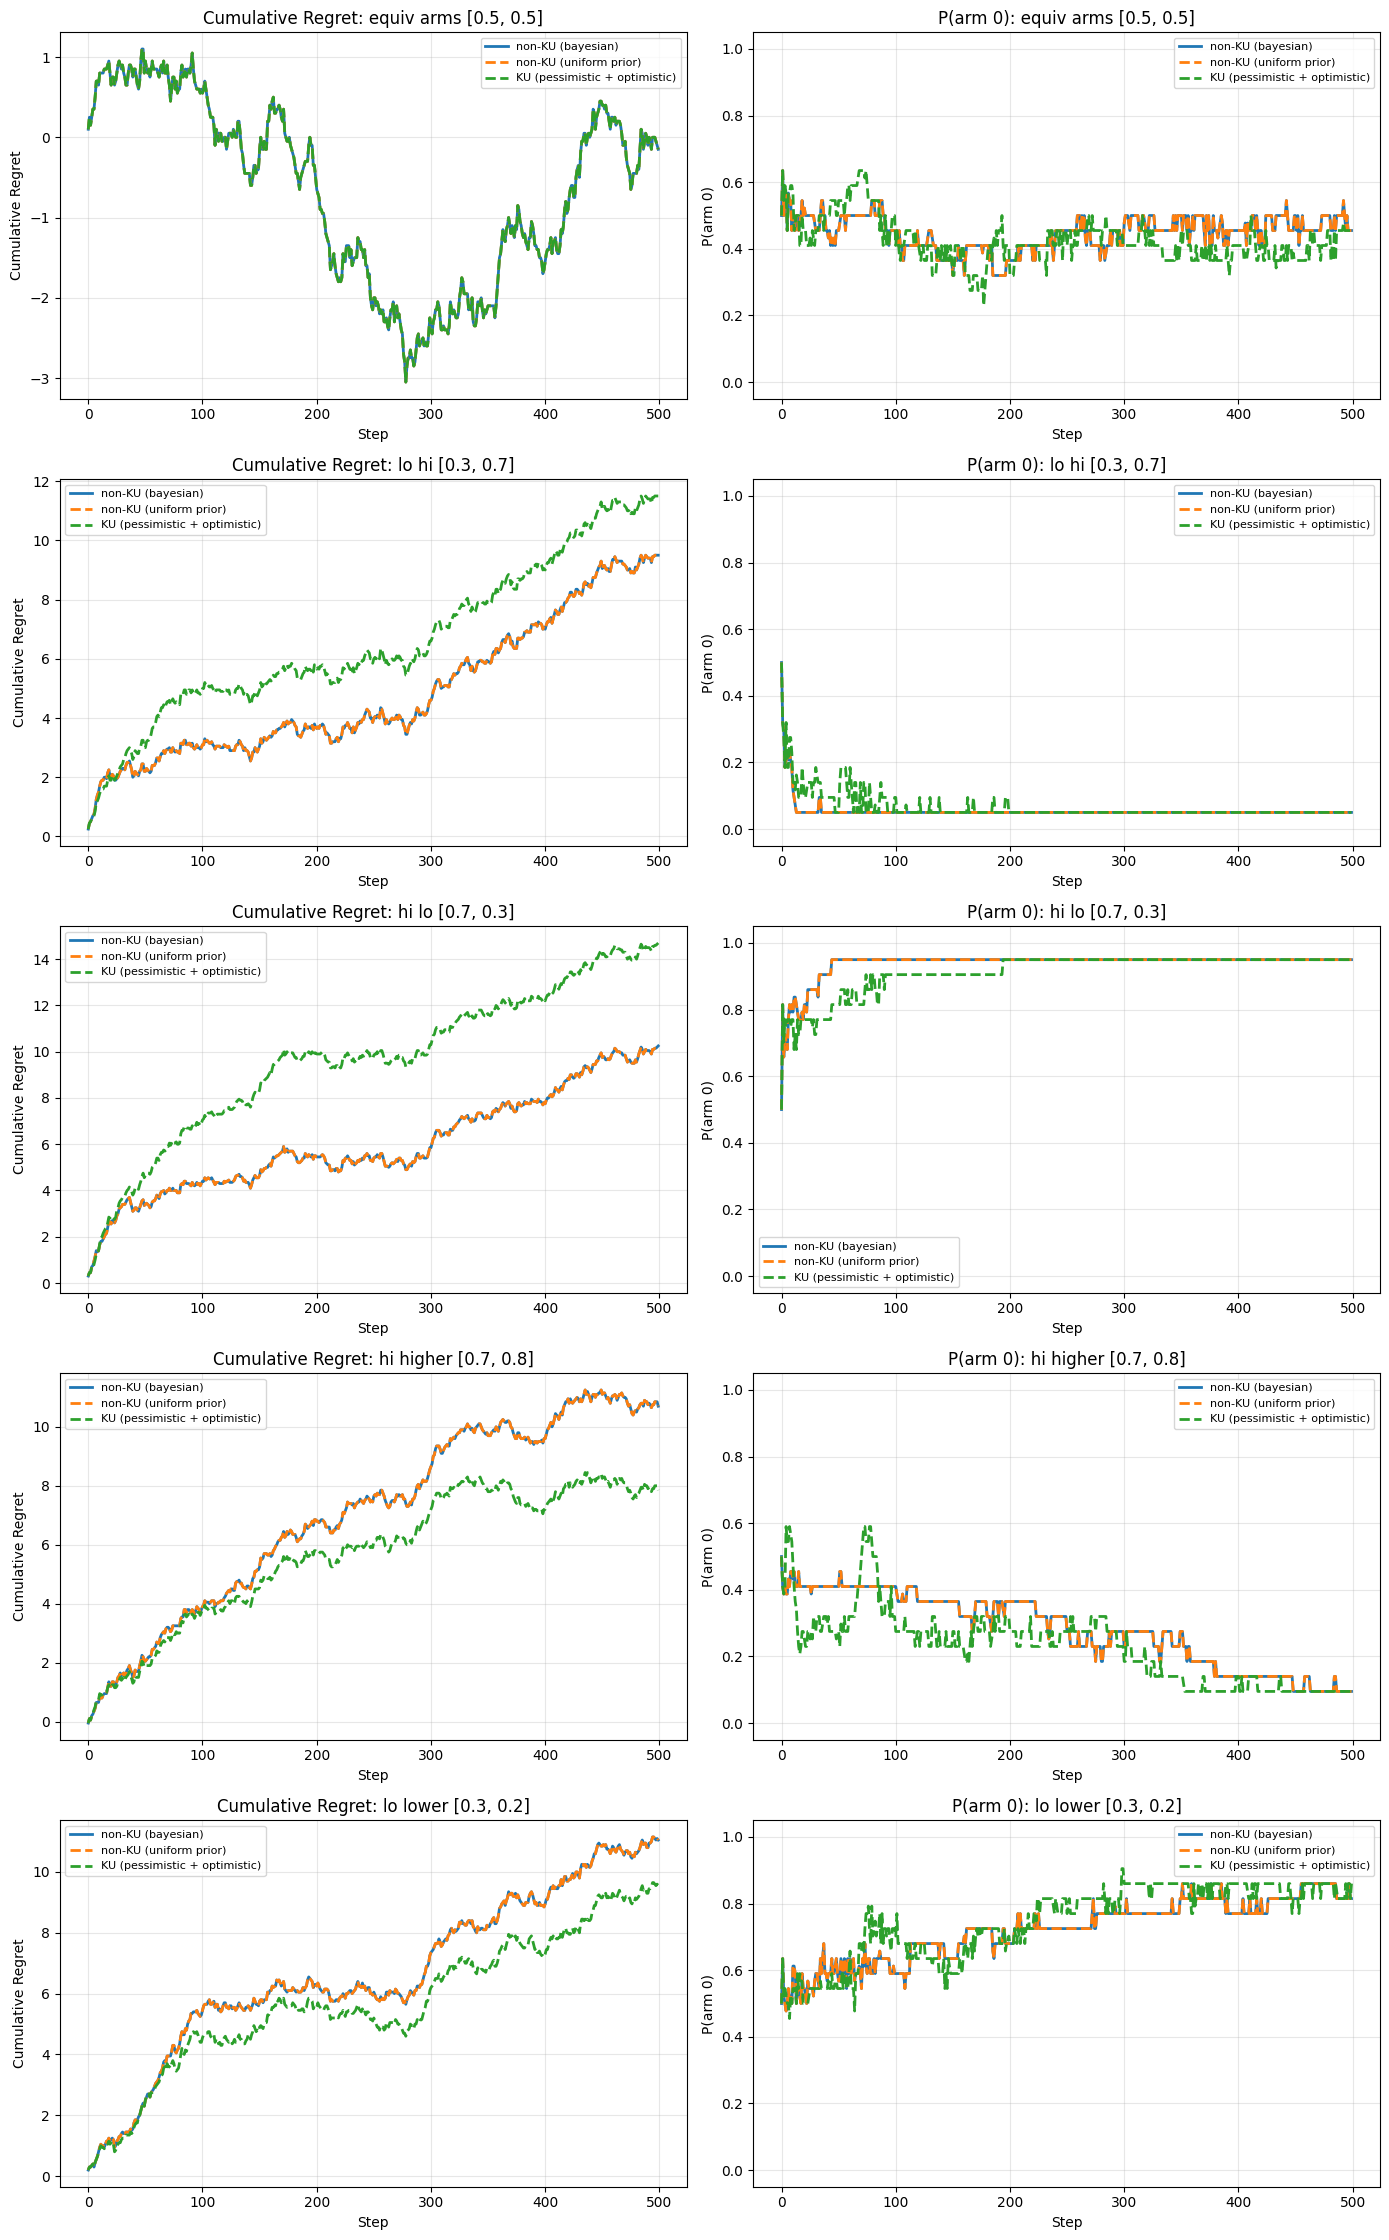

In [16]:
num_envs = len(env_probs)
fig, axes = plt.subplots(num_envs, 2, figsize=(14, 4.5 * num_envs))

for i, (env_label, agent_results) in enumerate(results_bandit.items()):
    # Cumulative regret
    ax = axes[i, 0]
    for agent_name, res in agent_results.items():
        avg = res["average_reward"][0, :]
        regret = np.cumsum(res["optimal_reward"] - avg)
        ls = "-" if "bayesian" in agent_name else "--"
        ax.plot(regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(f"Cumulative Regret: {env_label} {env_probs[env_label]}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Selection probabilities (arm 0)
    ax = axes[i, 1]
    for agent_name, res in agent_results.items():
        p0 = res["probabilities"][:, :, 0].mean(axis=0)
        ls = "-" if "bayesian" in agent_name else "--"
        ax.plot(p0, label=f"{agent_name}", linewidth=2, ls=ls)
    ax.set_title(f"P(arm 0): {env_label} {env_probs[env_label]}")
    ax.set_xlabel("Step")
    ax.set_ylabel("P(arm 0)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Effect of g (Counterfactual Value)

`g` controls how much value the agent assigns to the non-observed branch of the outcome space during KU updates.

- **g = 1.0** (default): Full value on counterfactual — preserves cohomogeneity (lambda + b = 1). Recommended by IB literature.
- **g = 0.5**: Partial counterfactual value — discounts unseen outcomes.
- **g = 0.0**: Zero counterfactual value — completely ignores what would have happened on the other branch. Degenerates to independent Bayesian updates per measure (no cross-measure interaction).

In [5]:
g_values = [0.0, 0.5, 1.0]
ku_beliefs = [
    make_bernoulli([1, 1], [3, 3]),
    make_bernoulli([3, 3], [1, 1]),
]

results_g = {}
for g in g_values:
    agent = InfraBayesianAgent(**shared, beliefs=ku_beliefs, g=g)
    env = construct_environment("bernoulli-bandit", options)
    label = f"KU, g={g}"
    print(f"Running: bernoulli-bandit / {label}")
    results_g[label] = simulate(env, agent, options)
    res = results_g[label]
    print(f"  optimal: {res['optimal_reward']:.4f}  "
          f"final avg: {res['average_reward'][0, -50:].mean():.4f}")

Running: bernoulli-bandit / KU, g=0.0
  optimal: 0.7278  final avg: 0.7070
Running: bernoulli-bandit / KU, g=0.5
  optimal: 0.7278  final avg: 0.7070
Running: bernoulli-bandit / KU, g=1.0
  optimal: 0.7278  final avg: 0.7120


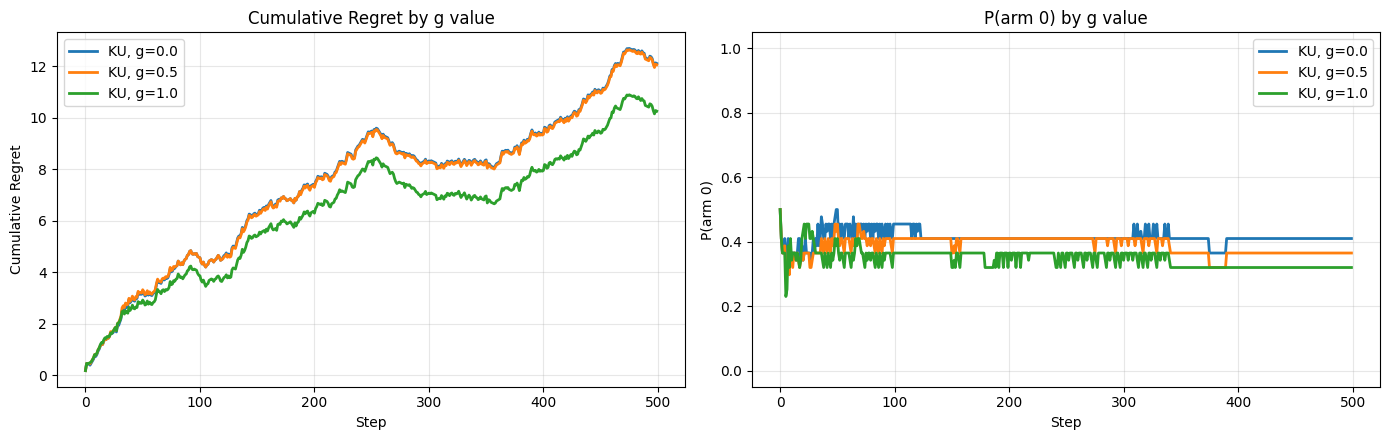

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for label, res in results_g.items():
    avg = res["average_reward"][0, :]
    regret = np.cumsum(res["optimal_reward"] - avg)
    ax.plot(regret, label=label, linewidth=2)
ax.set_title("Cumulative Regret by g value")
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative Regret")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for label, res in results_g.items():
    p0 = res["probabilities"][:, :, 0].mean(axis=0)
    ax.plot(p0, label=label, linewidth=2)
ax.set_title("P(arm 0) by g value")
ax.set_xlabel("Step")
ax.set_ylabel("P(arm 0)")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Internal A-Measure State (Lambda, Offset, Cohomogeneity)

Run a single KU episode manually and track how each a-measure's internal state evolves.

With `g=1.0`, **cohomogeneity** should be preserved: `lambda_k + b_k = 1` for all measures at every step. This is a key mathematical property — it means the a-measures remain normalized.

In [7]:
from ibrl.utils import sample_action

# Manual single-run simulation to capture internal state
env = construct_environment("bernoulli-bandit", options)
agent = InfraBayesianAgent(
    **shared,
    beliefs=[
        make_bernoulli([1, 1], [3, 3]),  # pessimistic
        make_bernoulli([3, 3], [1, 1]),  # optimistic
    ],
    g=1.0,
)

env.reset()
agent.reset()

num_steps = 200
history = {
    "lambda_A": [], "lambda_B": [],
    "offset_A": [], "offset_B": [],
    "cohomogeneity_A": [], "cohomogeneity_B": [],
    "reward_model_min": [],  # min over measures, per arm
}

for step in range(num_steps):
    probs = agent.get_probabilities()
    action = sample_action(agent.random, probs)
    outcome = env.step(probs, action)
    agent.update(probs, action, outcome)

    # Capture internal state
    mA, mB = agent.infradist.measures
    lam_A, lam_B = np.exp(mA.log_scale), np.exp(mB.log_scale)
    history["lambda_A"].append(lam_A)
    history["lambda_B"].append(lam_B)
    history["offset_A"].append(mA.offset)
    history["offset_B"].append(mB.offset)
    history["cohomogeneity_A"].append(lam_A + mA.offset)
    history["cohomogeneity_B"].append(lam_B + mB.offset)
    history["reward_model_min"].append(
        agent.infradist.expected_reward_model({"step": agent.step})
    )

print(f"Final lambda_A={history['lambda_A'][-1]:.6f}, offset_A={history['offset_A'][-1]:.6f}")
print(f"Final lambda_B={history['lambda_B'][-1]:.6f}, offset_B={history['offset_B'][-1]:.6f}")
print(f"Cohomogeneity A: {history['cohomogeneity_A'][-1]:.10f}")
print(f"Cohomogeneity B: {history['cohomogeneity_B'][-1]:.10f}")

Final lambda_A=1.000000, offset_A=0.000000
Final lambda_B=85.829960, offset_B=4647973084577724416.000000
Cohomogeneity A: 1.0000000000
Cohomogeneity B: 4647973084577724416.0000000000


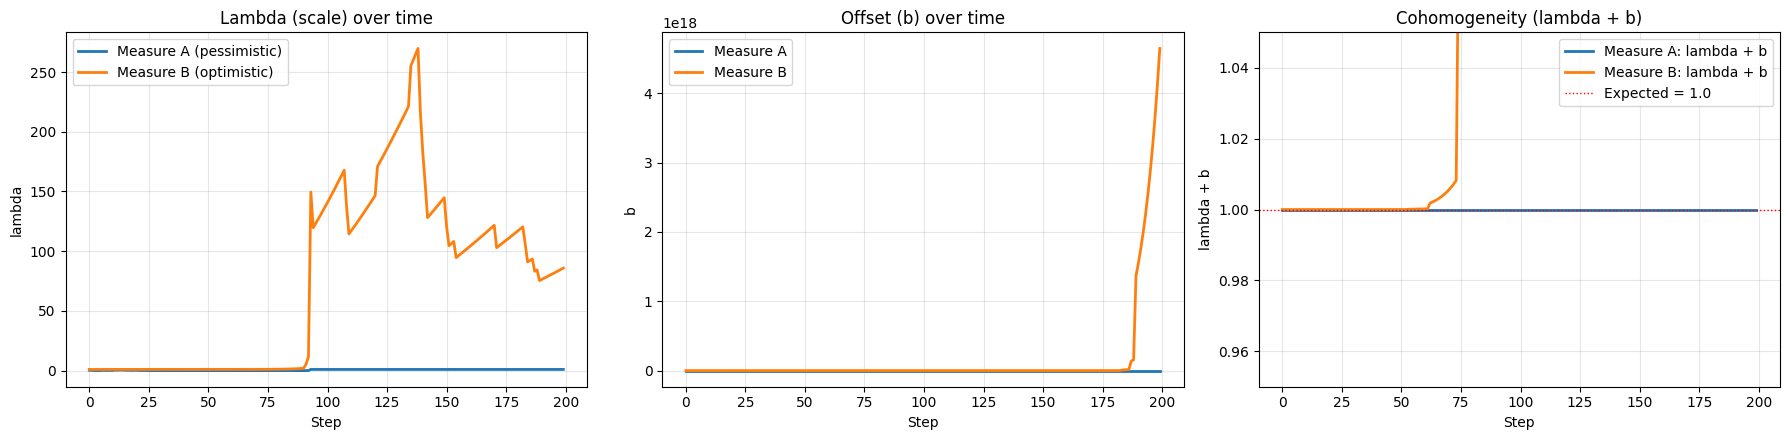

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Lambda evolution
ax = axes[0]
ax.plot(history["lambda_A"], label="Measure A (pessimistic)", linewidth=2)
ax.plot(history["lambda_B"], label="Measure B (optimistic)", linewidth=2)
ax.set_title("Lambda (scale) over time")
ax.set_xlabel("Step")
ax.set_ylabel("lambda")
ax.legend()
ax.grid(True, alpha=0.3)

# Offset evolution
ax = axes[1]
ax.plot(history["offset_A"], label="Measure A", linewidth=2)
ax.plot(history["offset_B"], label="Measure B", linewidth=2)
ax.set_title("Offset (b) over time")
ax.set_xlabel("Step")
ax.set_ylabel("b")
ax.legend()
ax.grid(True, alpha=0.3)

# Cohomogeneity check: lambda + b should stay at 1.0
ax = axes[2]
ax.plot(history["cohomogeneity_A"], label="Measure A: lambda + b", linewidth=2)
ax.plot(history["cohomogeneity_B"], label="Measure B: lambda + b", linewidth=2)
ax.axhline(y=1.0, color="red", linestyle=":", linewidth=1, label="Expected = 1.0")
ax.set_title("Cohomogeneity (lambda + b)")
ax.set_xlabel("Step")
ax.set_ylabel("lambda + b")
ax.set_ylim(0.95, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

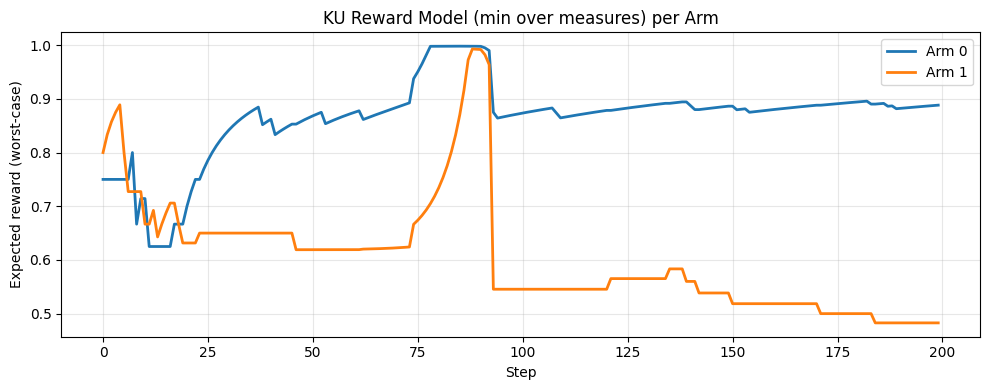

In [9]:
# Reward model evolution (min over measures)
reward_models = np.array(history["reward_model_min"])

fig, ax = plt.subplots(figsize=(10, 4))
for arm in range(n):
    ax.plot(reward_models[:, arm], label=f"Arm {arm}", linewidth=2)
ax.set_title("KU Reward Model (min over measures) per Arm")
ax.set_xlabel("Step")
ax.set_ylabel("Expected reward (worst-case)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. KU on Newcomb-Like Environments

NewcombLikeBelief with KU on Newcomb and coordination games. Since these environments produce rewards outside [0, 1], we use a utility mapping to normalize rewards for the IB update.

**KU setup**: Two NewcombLikeBelief measures with different prior means — one optimistic, one pessimistic about unseen cells.

In [10]:
newcomb_envs = ["newcomb", "damascus", "asymmetric-damascus", "coordination"]

# Newcomb rewards range [0, 15]. Utility mapping normalizes to [0, 1].
utility_newcomb = lambda r: np.clip(r / 15.0, 0.0, 1.0)

def make_newcomb_agents():
    return {
        "non-KU": InfraBayesianAgent(
            **shared,
            beliefs=[NewcombLikeBelief(num_actions=n, prior_mean=0.5)],
            utility=utility_newcomb,
        ),
        "KU (pessimistic + optimistic)": InfraBayesianAgent(
            **shared,
            beliefs=[
                NewcombLikeBelief(num_actions=n, prior_mean=0.3),  # pessimistic
                NewcombLikeBelief(num_actions=n, prior_mean=0.7),  # optimistic
            ],
            utility=utility_newcomb,
        ),
    }

results_newcomb = {}
for env_name in newcomb_envs:
    results_newcomb[env_name] = {}
    agents = make_newcomb_agents()
    for agent_name, agent in agents.items():
        env = construct_environment(env_name, options)
        print(f"Running: {env_name} / {agent_name}")
        results_newcomb[env_name][agent_name] = simulate(env, agent, options)
        res = results_newcomb[env_name][agent_name]
        print(f"  optimal: {res['optimal_reward']:.4f}  "
              f"final avg: {res['average_reward'][0, -50:].mean():.4f}")

Running: newcomb / non-KU
  optimal: 10.0000  final avg: 9.6550
Running: newcomb / KU (pessimistic + optimistic)
  optimal: 10.0000  final avg: 8.4650
Running: damascus / non-KU
  optimal: 5.0000  final avg: 4.8000
Running: damascus / KU (pessimistic + optimistic)
  optimal: 5.0000  final avg: 4.8000
Running: asymmetric-damascus / non-KU
  optimal: 6.6667  final avg: 5.4250
Running: asymmetric-damascus / KU (pessimistic + optimistic)
  optimal: 6.6667  final avg: 5.4250
Running: coordination / non-KU
  optimal: 2.0000  final avg: 1.7570
Running: coordination / KU (pessimistic + optimistic)
  optimal: 2.0000  final avg: 1.7570


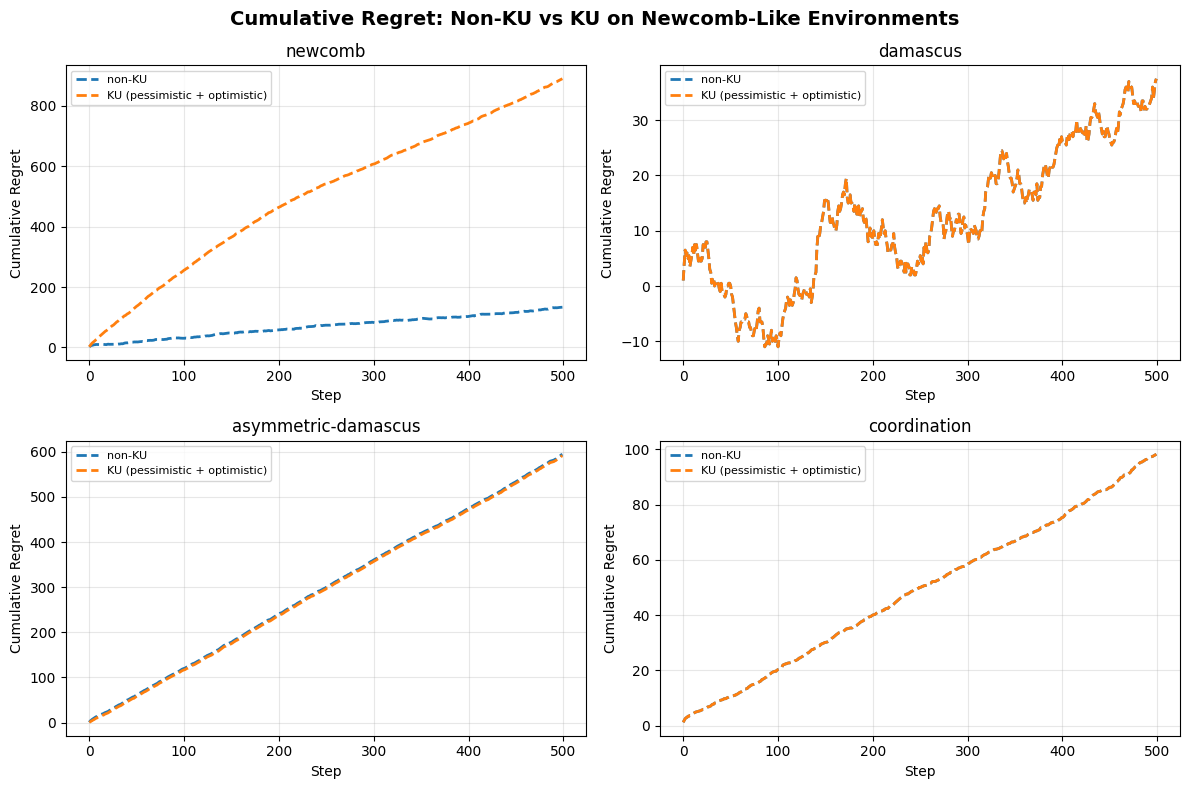

In [11]:
cols = 2
rows = math.ceil(len(newcomb_envs) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for i, env_name in enumerate(newcomb_envs):
    ax = axes[i]
    for agent_name, res in results_newcomb[env_name].items():
        avg = res["average_reward"][0, :]
        regret = np.cumsum(res["optimal_reward"] - avg)
        ls = "--" if "KU" in agent_name else "-"
        ax.plot(regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(env_name)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(newcomb_envs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Cumulative Regret: Non-KU vs KU on Newcomb-Like Environments",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

In [ ]:
# Bernoulli bandit summary
print("=== Bernoulli Bandit ===")
print(f"{'Environment':<15} {'Agent':<35} {'Optimal':>8} {'Final Avg':>10}")
print("-" * 70)
for env_label, agent_results in results_bandit.items():
    for agent_name, res in agent_results.items():
        avg = res["average_reward"][0, -50:].mean()
        print(f"{env_label:<15} {agent_name:<35} {res['optimal_reward']:>8.3f} {avg:>10.3f}")

print()

# g comparison
print("=== Effect of g (Bernoulli Bandit, KU) ===")
print(f"{'Agent':<35} {'Optimal':>8} {'Final Avg':>10}")
print("-" * 55)
for label, res in results_g.items():
    avg = res["average_reward"][0, -50:].mean()
    print(f"{label:<35} {res['optimal_reward']:>8.3f} {avg:>10.3f}")

print()

# Newcomb-like summary
print("=== Newcomb-Like Environments ===")
print(f"{'Environment':<25} {'Agent':<30} {'Optimal':>8} {'Final Avg':>10}")
print("-" * 75)
for env_name in newcomb_envs:
    for agent_name, res in results_newcomb[env_name].items():
        avg = res["average_reward"][0, -50:].mean()
        print(f"{env_name:<25} {agent_name:<30} {res['optimal_reward']:>8.3f} {avg:>10.3f}")